<a href="https://colab.research.google.com/github/2303A52060/23CSBTB39-40/blob/main/Hashing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Introduction to Hashing:

Hashing refers to the process of generating a small sized output (that can be used as index in a table) from an input of typically large and variable size. Hashing uses mathematical formulas known as hash functions to do the transformation. This technique determines an index or location for the storage of an item in a data structure called Hash Table.
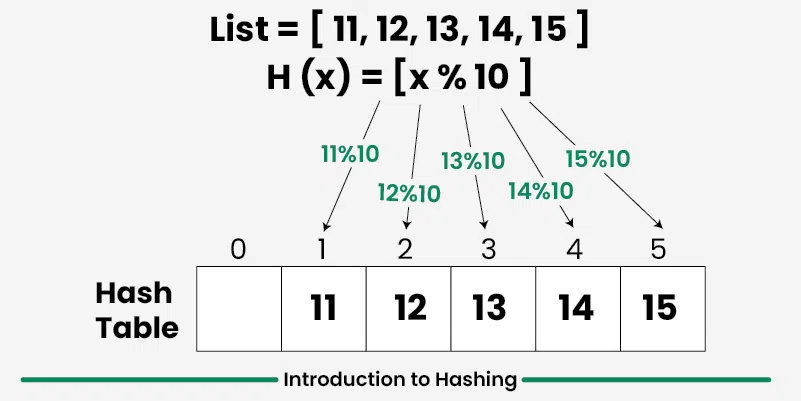


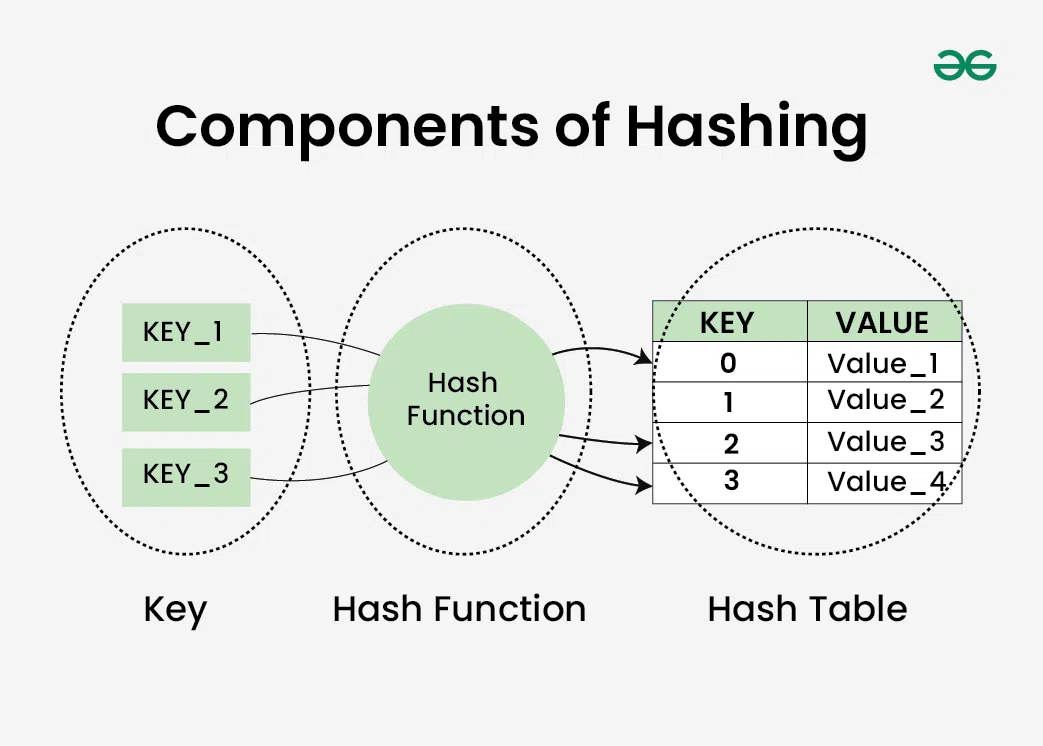

Linear Probing in Hash Tables:

In Open Addressing, all elements are stored directly in the hash table itself. Therefore, the size of the hash table must be greater than the total number of keys. To maintain good performance, the load factor (number of keys divided by table size) should be kept below a certain limit, usually 0.7. If needed, the table size can be increased by rehashing the existing elements.

Insert(k): The hash function is applied to the key to generate an index. If that slot is occupied, probing continues until an empty or deleted slot is found, and the key is inserted there.

Search(k): The hash function generates the starting index, and probing continues until the key is found or an empty slot is encountered.

Delete(k): Instead of removing an element completely, its slot is marked as "deleted" using a dummy node (key = –1, value = –1). This ensures that searching does not stop prematurely and that future insert operations can reuse deleted slots.

This process ensures that every key is mapped to a valid index within the hash table and that values are stored based on the position generated by the hash function. Searching, insertion, and deletion take O(1) average time, but in the worst case, these operations may take O(n) time if the table becomes too full or has many deleted slots


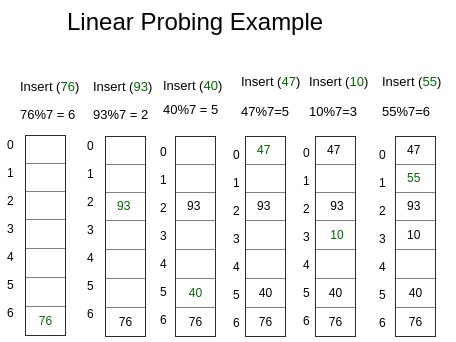

In [1]:
class hashNode:

    # constructor
    def __init__(self, key, value):
        self.key = key
        self.value = value

class hashMap:

    # constructor
    def __init__(self):
        self.capacity = 20
        self.size = 0
        self.arr = [None] * self.capacity
        self.dummy = hashNode(-1, -1)

    # hash function
    def hashCode(self, key):
        return key % self.capacity

    # insert key-value pair
    def insertNode(self, key, value):
        temp = hashNode(key, value)
        hashIndex = self.hashCode(key)

        while self.arr[hashIndex] is not None and \
              self.arr[hashIndex].key != key and \
              self.arr[hashIndex].key != -1:
            hashIndex = (hashIndex + 1) % self.capacity

        if self.arr[hashIndex] is None or \
                    self.arr[hashIndex].key == -1:
            self.size += 1
        self.arr[hashIndex] = temp

    # delete by key
    def deleteNode(self, key):
        hashIndex = self.hashCode(key)

        while self.arr[hashIndex] is not None:
            if self.arr[hashIndex].key == key:
                temp = self.arr[hashIndex]
                self.arr[hashIndex] = self.dummy
                self.size -= 1
                return temp.value
            hashIndex = (hashIndex + 1) % self.capacity

        return -1

    # get value by key
    def get(self, key):
        hashIndex = self.hashCode(key)
        counter = 0

        while self.arr[hashIndex] is not None:
            if counter > self.capacity:
                return -1
            if self.arr[hashIndex].key == key:
                return self.arr[hashIndex].value
            hashIndex = (hashIndex + 1) % self.capacity
            counter += 1

        return -1

    # return map size
    def sizeofMap(self):
        return self.size

    # check if map is empty
    def isEmpty(self):
        return self.size == 0

    # display all key-value pairs
    def display(self):
        for node in self.arr:
            if node is not None and node.key != -1:
                print(f"{node.key} {node.value}")

if __name__ == "__main__":
    h = hashMap()
    h.insertNode(1, 1)
    h.insertNode(2, 2)
    h.insertNode(2, 3)
    h.display()
    print(h.sizeofMap())
    print(h.deleteNode(2))
    print(h.sizeofMap())
    print(str(h.isEmpty()).lower())
    print(h.get(2))

1 1
2 3
2
3
1
false
-1


Diistinct elements in a given array
Last Updated : 29 Apr, 2026
Given an array arr[] of integers which may or may not contain duplicate elements. Your task is to remove duplicate elements. Your result should have elements according their first appearance in the input array.

Examples:

Input: arr[] = [1, 2, 3, 1, 4, 2]
Output: [1, 2, 3, 4]
Explanation: 2 and 1 have more than 1 occurence.

Input: arr[] = [1, 2, 3, 4]
Output: [1, 2, 3, 4]
Explanation: There is no duplicate element.


[Naive Approach] Using Nested loops - O(n^2) Time and O(1) Space::



In [2]:
def removeDuplicate(arr):
    res = []

    for i in range(len(arr)):
        found = False

        # Check if already present
        for j in range(i):
            if arr[i] == arr[j]:
                found = True
                break

        # If not found, add to result
        if not found:
            res.append(arr[i])

    return res


# Driver Code
arr = [1, 2, 3, 1, 4, 2]
res = removeDuplicate(arr)

for ele in res:
    print(ele, end=' ')

1 2 3 4 

[Expected Approach] Using Hash Set - O(n) Time and O(n) Space:



In [3]:
def removeDuplicate(arr):
    # Creates an empty hashset
    s = set()
    v = []

    # Traverse the input array
    for i in range(len(arr)):
        # If not present, then put it in
        # hashtable and print it
        if arr[i] not in s:
            s.add(arr[i])
            v.append(arr[i])
    return v

# Driver Code
arr = [1, 2, 3, 1, 4, 2]
res = removeDuplicate(arr)
for ele in res:
    print(ele, end=' ')

1 2 3 4 

Union of Two Arrays:

Given two arrays a[] and b[], Return union of both the arrays in any order.
Note: Union of two arrays is an array having all distinct elements that are present in either array.

Examples:

Input : a[] = [1, 2, 3, 2, 1], b[] = [3, 2, 2, 3, 3, 2]
Output : [3, 2, 1]
Explanation: 3, 2 and 1 are the distinct elements present in either array.

Input : a[] = [1, 2, 3], b[] = [4, 5, 6]
Output : [1, 2, 3, 4, 5, 6]
Explanation: 1, 2, 3, 4, 5 and 6 are the elements present in either array.



In [4]:
def findUnion(a, b):
    res = []

    # Traverse through a[] and search every element
    # a[i] in result
    for i in range(len(a)):

        # check if the element is already
        # in the result to avoid duplicates
        j = 0
        while j < len(res):
            if res[j] == a[i]:
                break
            j += 1

        if j == len(res):
            res.append(a[i])

    # Traverse through b[] and search every element
    # b[i] in result
    for i in range(len(b)):

        # check if the element is already
        # in the result to avoid duplicates
        j = 0
        while j < len(res):
            if res[j] == b[i]:
                break
            j += 1
        if j == len(res):
            res.append(b[i])

    return res


if __name__ == "__main__":
    a = [1, 2, 3, 2, 1]
    b = [3, 2, 2, 3, 3, 2]

    res = findUnion(a, b)

    for value in res:
        print(value, end=" ")

1 2 3 

In [5]:
#[Expected Approach] Using Hash Set - O(n+m) Time and O(n+m) Space

def findUnion(a, b):
    st = set()

    # Put all elements of a[] in st
    for i in range(len(a)):
        st.add(a[i])

    # Put all elements of b[] in st
    for i in range(len(b)):
        st.add(b[i])

    res = []

    # iterate through the set
    # to fill the result array
    for it in st:
        res.append(it)

    return res

if __name__ == "__main__":
    a = [1, 2, 3, 2, 1]
    b = [3, 2, 2, 3, 3, 2]

    res = findUnion(a, b)

    for i in range(len(res)):
        print(res[i], end = ' ')

1 2 3 

Two Sum - Pair with given Sum:

Given an array arr[] of n integers and a target value, check if there exists a pair whose sum equals the target. This is a variation of the 2-Sum problem.

Examples:

Input: arr[] = [0, -1, 2, -3, 1], target = -2
Output: true
Explanation: There is a pair (1, -3) with the sum equal to given target, 1 + (-3) = -2.

Input: arr[] = [1, -2, 1, 0, 5], target = 0
Output: false
Explanation: There is no pair with sum equals to given target.

In [6]:
#Sorting using binary search

# Function to perform binary search
def binarySearch(arr, left, right, target):
    while left <= right:
        mid = left + (right - left) // 2

        if arr[mid] == target:
            return True
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1
    return False

def twoSum(arr, target):
    arr.sort()

    for i in range(len(arr)):
        complement = target - arr[i]

        # Use binary search to find the complement
        if binarySearch(arr, i + 1,
                    len(arr) - 1, complement):
            return True

    # If no pair is found
    return False

if __name__ == "__main__":
    arr = [0, -1, 2, -3, 1]
    target = -2

    if twoSum(arr, target):
        print("true")
    else:
        print("false")

true


In [7]:
#[Better Approach 2] Sorting and Two-Pointer Technique - O(n × log(n)) time and O(1) space
def twoSum(arr, target):
    arr.sort()
    left, right = 0, len(arr) - 1

    # Iterate while left pointer is less than right
    while left < right:
        sum = arr[left] + arr[right]

        # Check if the sum matches the target
        if sum == target:
            return True
        elif sum < target:

            # Move left pointer to the right
            left += 1
        else:

            # Move right pointer to the left
            right -= 1

    # If no pair is found
    return False

if __name__ == "__main__":
    arr = [0, -1, 2, -3, 1]
    target = -2
    if twoSum(arr, target):
        print("true")
    else:
        print("false")

true


Fizz Buzz:

Given an integer n, for every positive integer i <= n, the task is to print,

"FizzBuzz" if i is divisible by 3 and 5,

"Fizz" if i is divisible by 3,

"Buzz" if i is divisible by 5

"i" as a string, if none of the conditions are true.

Examples:

Input: n = 3
Output: ["1", "2", "Fizz"]

Input: n = 10
Output: ["1", "2", "Fizz", "4", "Buzz", "Fizz", "7", "8", "Fizz", "Buzz"]

Input: n = 20
Output: ["1", "2", "Fizz", "4", "Buzz", "Fizz", "7", "8", "Fizz", "Buzz", "11", "Fizz", "13", "14", "FizzBuzz", "16", "17", "Fizz", "19", "Buzz"]

In [8]:
#[Naive Approach] By checking every integer individually
# Python program for Fizz Buzz Problem
# by checking every integer individually

def fizzBuzz(n):
    res = []

    for i in range(1, n + 1):

        # Check if i is divisible by both 3 and 5
        if i % 3 == 0 and i % 5 == 0:

            # Add "FizzBuzz" to the result list
            res.append("FizzBuzz")

        # Check if i is divisible by 3
        elif i % 3 == 0:

            # Add "Fizz" to the result list
            res.append("Fizz")

        # Check if i is divisible by 5
        elif i % 5 == 0:

            # Add "Buzz" to the result list
            res.append("Buzz")
        else:

            # Add the current number as a string to the
            # result list
            res.append(str(i))

    return res


if __name__ == "__main__":
    n = 20
    res = fizzBuzz(n)
    print(' '.join(res))

1 2 Fizz 4 Buzz Fizz 7 8 Fizz Buzz 11 Fizz 13 14 FizzBuzz 16 17 Fizz 19 Buzz


In [9]:
#[Better Approach] By String Concatenation
# Python program for Fizz Buzz Problem
# by checking every integer individually
# with string concatenation

def fizzBuzz(n):
    res = []

    for i in range(1, n + 1):

        # Initialize an empty string for the current result
        s = ""

        # Divides by 3, add Fizz
        if i % 3 == 0:
            s += "Fizz"

        # Divides by 5, add Buzz
        if i % 5 == 0:
            s += "Buzz"

        # Not divisible by 3 or 5, add the number
        if not s:
            s += str(i)

        # Append the current result to the list
        res.append(s)

    return res

if __name__ == "__main__":
    n = 20
    res = fizzBuzz(n)

    for s in res:
        print(s, end=" ")


1 2 Fizz 4 Buzz Fizz 7 8 Fizz Buzz 11 Fizz 13 14 FizzBuzz 16 17 Fizz 19 Buzz 

In [10]:
#[Expected Approach] Using Hash Map or Dictionary
# Python program for Fizz Buzz Problem
# by checking every integer individually
# with hashing

def fizzBuzz(n):
    res = []

    # Dictionary to store all FizzBuzz mappings.
    mp = {3: "Fizz", 5: "Buzz"}
    divisors = [3, 5]

    for i in range(1, n + 1):
        s = ""

        for d in divisors:

            # If the i is divisible by d, add the
          	# corresponding string mapped with d
            if i % d == 0:
                s += mp[d]

        # Not divisible by 3 or 5, add the number
        if not s:
            s += str(i)

        # Append the current answer str to the result list
        res.append(s)

    return res

if __name__ == "__main__":
    n = 20
    res = fizzBuzz(n)

    for s in res:
        print(s, end=" ")

1 2 Fizz 4 Buzz Fizz 7 8 Fizz Buzz 11 Fizz 13 14 FizzBuzz 16 17 Fizz 19 Buzz 

Roman to Integer Conversion:

Given a string s representing a Roman numeral, find it's corresponding integer value.

Roman numerals are formed using the following symbols: I = 1, V = 5, X = 10, L

= 50, C = 100, D = 500, and M = 1000.

Numbers are typically formed by combining these symbols from left to right,

adding or subtracting their values based on specific rules.

How does the conversion work?

If a smaller value symbol comes before, we subtract. Otherwise, we add.

In IV, I comes before V and V has a larger value 5. So our result is 5 - 1 = 4.

In VI, V comes before I and I has a smaller value 1. So our result is 5 + 1 = 6.

In II, we have same values, so we add and get 1 + 1 = 2

In case of more than 2 characters, we traverse from left to right and group

only when we see a greater value character after a smaller value character. For

example MXVII is 1000 + 10 + 5 + 1 + 1 = 1017. And XLVII is (50 - 10) + 5 + 1 +

1 = 47. Note that L is larger and comes after X.

Examples:

Input: s = "IX"

Output: 9

Explanation: IX is a Roman symbol which represents 10 - 1 = 9

Input: s = "XL"

Output: 40

Explanation: XL is a Roman symbol which represents 50 - 10 = 40

Input: s = "MCMIV"
Output: 1904
Explanation: M is 1000, CM is 1000 - 100 = 900, and IV is 4. So we have total as 1000 + 900 + 4 = 1904

In [11]:
#[Expected Approach 2] Using Hashing - O(n) time and O(1) space

def romanToDecimal(s):
    romanMap = {'I': 1, 'V': 5, 'X': 10, 'L': 50,
                'C': 100, 'D': 500, 'M': 1000}

    res = 0
    i = 0
    while i < len(s):

        # if the current value is less than the next value,
        # subtract current from next and add to res
        if i + 1 < len(s) and romanMap[s[i]] < romanMap[s[i + 1]]:
            res += romanMap[s[i + 1]] - romanMap[s[i]]

            # skip the next symbol
            i += 1
        else:

            # otherwise, add the current value to res
            res += romanMap[s[i]]
        i += 1

    return res

if __name__ == "__main__":
    s = "IX"
    print(romanToDecimal(s))

9


Isomorphic Strings Check:

Given two strings s1 and s2 of equal length, consisting only of lowercase

English letters, determine if they are isomorphic.

Two strings are isomorphic if characters in s1 can be replaced to get s2 such

that:

Each character in s1 maps to a unique character in s2.

The mapping is consistent throughout the string.
The order of characters is preserved.

Examples:

Input: s1 = "aab", s2 = "xxy"

Output: true

Explanation: Each character in s1 can be consistently mapped to a unique

character in s2 (a → x, b → y).

Input: s1 = "aab", s2 = "xyz"

Output: false

Explanation: Same character 'a' in s1 maps to two different characters 'x' and

'y' in s2.

Input: s1 = "abc", s2 = "xxz"

Output: false

Explanation: Two different characters 'a' and 'b' in s1 maps with same

Character 'x' in s2.


In [12]:
def areIsomorphic(s1, s2):
    m1 = {}
    m2 = {}

    for i in range(len(s1)):

        # If character not seen before, store its
        # first occurrence index
        if s1[i] not in m1:
            m1[s1[i]] = i
        if s2[i] not in m2:
            m2[s2[i]] = i

        # Check if the first occurrence indices match
        if m1[s1[i]] != m2[s2[i]]:
            return False

    return True

if __name__ == "__main__":
    s1 = "aab"
    s2 = "xxy"
    if areIsomorphic(s1, s2):
        print("true")
    else:
        print("false")

true


In [13]:
#[Expected Approach 2] Fixed-Size Array Mapping Approach - O(n) Time and O(1) Space
def areIsomorphic(s1, s2):
    n = len(s1)

    # marked[v] is true if character
    # 'a'+v from s2 is already used
    marked = [False] * 26

    # map[u] stores the character index
    # in s2 that s1's 'a'+u maps to
    map = [-1] * 26

    for i in range(n):
        u = ord(s1[i]) - ord('a')
        v = ord(s2[i]) - ord('a')

        # If s1[i] has not been mapped yet
        if map[u] == -1:

            # If s2[i] is already used
            # by another character
            if marked[v]:
                return False

            # Assign mapping and mark s2[i] as used
            map[u] = v
            marked[v] = True
        # If already mapped, check for consistency
        elif map[u] != v:
            return False

    return True

if __name__ == "__main__":
    s1 = "aab"
    s2 = "xxy"

    print("true\n" if areIsomorphic(s1, s2) else "false\n")

true



In [14]:
#[Expected Approach 3] Using HashMap and Set - O(n) Time and O(1) Space
def areIsomorphic(s1, s2):

    # character mapping from s1 to s2
    m1 = {}

    # Already mapped characters in s2
    set2 = set()

    for c1, c2 in zip(s1, s2):

        # If c1 is already mapped
        if c1 in m1:

            # Check if it maps to the current character in s2
            if m1[c1] != c2:
                return False
        else:

            # Ensure c2 is not already mapped to another character
            if c2 in set2:
                return False

            # Create a new mapping and mark c2 as mapped
            m1[c1] = c2
            set2.add(c2)
    return True


if __name__ == "__main__":
    s1 = "aab"
    s2 = "xxy"
    if areIsomorphic(s1, s2):
        print("true")
    else:
        print("false")

true


Hashing for Frequency:

Counting frequencies of array elements:

Given an array arr[] of non-negative integers which may contain duplicate elements. Return the frequency of each distinct element present in the array.

Examples:

Input:  arr[] = [10, 20, 10, 5, 20]

Output: [[5, 1], [10, 2], [20, 2]]

Explanation: Here 5 occurs once, 10 occurs 2 times and 20 occurs 2 times.

Input: arr[] = [10, 20, 20]

Output: [[10, 1], [20, 2]]

Explanation: Here 10 occurs 1 time, 20 occurs 2 times.

In [15]:
#[Better Approach] Using binary search

from bisect import bisect_left, bisect_right

def countFreq(arr):
    n = len(arr)

    # Sort array for binary search
    arr.sort()
    ans = []
    i = 0
    while i < n:

        # Find first and last occurrence of arr[i]
        # using bisect_left and bisect_right
        firstIndex = bisect_left(arr, arr[i])
        lastIndex = bisect_right(arr, arr[i]) - 1

        # Calculate frequency
        fre = lastIndex - firstIndex + 1
        ans.append([arr[i], fre])

        # Skip counted elements
        i = lastIndex + 1

    return ans

if __name__ == "__main__":
    arr = [10, 20, 10, 5, 20]
    ans = countFreq(arr)
    for x in ans:
        print(x[0], x[1])


5 1
10 2
20 2


In [16]:
#[Expected Solution] Using hashing - O(n) Time and O(n) Space

def countFreq(arr):
    # stores frequency of each number
    mp = {}
    # stores [number, frequency]
    ans = []

    # count frequency using dictionary
    for num in arr:
        mp[num] = mp.get(num, 0) + 1

    # Build the answer list from the frequency map
    for num, freq in mp.items():
        ans.append([num, freq])

    return ans


if __name__ == "__main__":
    arr = [10, 20, 10, 5, 20]

    ans = countFreq(arr)

    # sort the result in ascending order of the number
    ans.sort(key=lambda x: x[0])

    for x in ans:
        print(x[0], x[1])

5 1
10 2
20 2


Check if two Strings are Anagrams of each other

Given two non-empty strings s1 and s2 of lowercase letters, determine if they are anagrams — i.e., if they contain the same characters with the same frequencies.

Examples:

Input: s1 = “geeks”  s2 = “kseeg”

Output: true

Explanation: Both the string have same characters with same frequency. So, they are anagrams.

Input: s1 = "allergy", s2 = "allergyy"

Output: false

Explanation: Although the characters are mostly the same, s2 contains an extra 'y' character. Since the frequency of characters differs, the strings are not anagrams.

Input: s1 = "listen", s2 = "lists"

Output: false

Explanation: The characters in the two strings are not the same — some are missing or extra. So, they are not anagrams.


In [ ]:
#[Expected Approach 1] Using Hash Map or Dictionary - O(n + m) Time and O(1) Space

def areAnagrams(s1, s2):

    if len(s1) != len(s2):
        return False

    # create a hashmap to store
    # character frequencies
    charCount = {}

    # count frequency of each
    # character in string s1
    for ch in s1:
        charCount[ch] = charCount.get(ch, 0) + 1

    # count frequency of each
    # character in string s2
    for ch in s2:
        charCount[ch] = charCount.get(ch, 0) - 1

    # check if all frequencies are zero
    for value in charCount.values():
        if value != 0:
            return False

    return True

if __name__ == "__main__":

    s1 = "geeks"
    s2 = "kseeg"
    if areAnagrams(s1, s2):
        print("true")
    else:
        print("false")


In [17]:
#[Expected Approach 2] Using Frequency Array - O(n + m) Time and O(1) Space
def areAnagrams(s1, s2):

    if len(s1) != len(s2):
        return False

    # for lowercase a-z
    freq = [0] * 26

    # Count frequency of each character in s1
    for ch in s1:
        freq[ord(ch) - ord('a')] += 1

    # Subtract frequency using characters from s2
    for ch in s2:
        freq[ord(ch) - ord('a')] -= 1

    # Check if all frequencies are zero
    for count in freq:
        if count != 0:
            return False

    return True

if __name__ == "__main__":

    s1 = "geeks"
    s2 = "kseeg"

    if areAnagrams(s1, s2):
        print("true")
    else:
        print("false")

true


Longest Consecutive Subsequence

Given an array of integers, the task is to find the length of the longest subsequence such that elements in the subsequence are consecutive integers, the consecutive numbers can be in any order.

Examples:  

Input: arr[] = [2, 6, 1, 9, 4, 5, 3]

Output: 6

Explanation:  The longest consecutive subsequence [2, 6, 1, 4, 5, 3].

Input: arr[] = [1,1,1,2,2,3]

Output: 3

Explanation: The subsequence [1, 2,3] is the longest subsequence of consecutive

elements


In [18]:
#[Expected Approach] Using Hashing - O(n) Time and O(n) Space
def longestConsecutive(arr):
    st = set()
    res = 0

    # Hash all the array elements
    for val in arr:
        st.add(val)

    # Check each possible sequence from the start
    # then update length
    for val in arr:

        # If current element is the starting element of a sequence
        if val in st and (val - 1) not in st:

            # Then check for next elements in the sequence
            cur = val
            cnt = 0
            while cur in st:
                cur += 1
                cnt += 1

            # Update optimal length
            res = max(res, cnt)

    return res


if __name__ == "__main__":
    arr = [2, 6, 1, 9, 4, 5, 3]
    print(longestConsecutive(arr))

6


#Split array into minimum subsets

Given an array arr[] of distinct positive numbers, partition the array into minimum number of subsets (or subsequences) such that each subset contains consecutive numbers only.

Examples:

Input: arr[] = [100, 56, 5, 6, 102, 58, 101, 57, 7, 103, 59]

Output: 3

Explanation: [5, 6, 7], [ 56, 57, 58, 59] and [100, 101, 102, 103] are 3

subsets in which numbers are consecutive.

Input: arr[] = [10, 100, 105]

Output: 3

Explanation: [10], [100] and [105] are 3 subsets in which numbers are

consecutive.



In [19]:
def minSubsets(arr):

    # Create a set from the list
    s = set(arr)

    count = 0
    for x in arr:

        # Check for the start of a new subset
        if (x - 1) not in s:
            count += 1
    return count

if __name__ == "__main__":
    arr = [100, 56, 5, 6, 102, 58, 101, 57, 7, 103, 59]
    print(minSubsets(arr))


3
